In [1]:
from __future__ import annotations

import math
from dataclasses import asdict, dataclass
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def veilige_del(a: float, b: float, fallback: float = float("nan")) -> float:
    return fallback if abs(b) < 1e-16 else a / b


def mm(waarde_m: float) -> float:
    return 1000.0 * waarde_m


def m_uit_mm(waarde_mm: float) -> float:
    return waarde_mm / 1000.0


def toon_dataframe(naam: str, df: pd.DataFrame, max_rijen: int = 20) -> None:
    print(f"\n=== {naam.upper()} ===")
    if len(df) > max_rijen:
        print(df.head(max_rijen).to_string(index=False))
        print(f"... ({len(df)} rijen in totaal)")
    else:
        print(df.to_string(index=False))

In [3]:
try:
    resultaten_spindel
    _slag_m1_m = float(resultaten_spindel["export_voor_volgende_modules"].get(
        "m1_slag_m", 2.200))
except NameError:
    resultaten_spindel = {}
    _slag_m1_m = 2.200   # m — werkslag M1-as (update 10-03-2026)

if abs(_slag_m1_m - 3.0) < 0.01:
    import warnings
    warnings.warn(
        f"slag_m1_m = {_slag_m1_m} m — dit lijkt nog de OUDE waarde van 3.0 m. "
        "Controleer of notebook 03 correct geladen is.",
        stacklevel=2,
    )

In [ ]:
@dataclass(frozen=True)
class KabelItem:
    naam:                  str
    diameter_buiten_m:     float
    minimum_buigradius_m:  float
    aantal:                int = 1


@dataclass(frozen=True)
class ConfiguratieKabelrups:
    """
    Kabelbegeleidingsprofiel van de M1-as.
    slag_m wordt geladen vanuit notebook 03 (m1_slag_m).
    """
    slag_m:                    float = 2.200   # m — ALTIJD vanuit nb03 laden
    extra_lengte_eindstukken_m: float = 0.20

    max_vulgraad:              float = 0.60
    zijdelingse_speling_m:     float = 0.002
    boven_onder_speling_m:     float = 0.002
    scheiding_tussen_kabels_m: float = 0.002

    kabels: Tuple[KabelItem, ...] = (
        KabelItem("perslucht 4 mm (×2)",       0.008, 0.040, 2),
        KabelItem("MAGIC encoderkabel",         0.008, 0.040, 1),
        KabelItem("homing sensor",              0.006, 0.030, 1),
        KabelItem("upper limit switch",         0.006, 0.030, 1),
        KabelItem("lower limit switch",         0.006, 0.030, 1),
        KabelItem("safety stop / reserve",      0.006, 0.030, 1),
        KabelItem("M2 encoder/radar data (×4)", 0.006, 0.040, 4),
        KabelItem("M2 radar voeding (×2)",      0.006, 0.030, 2),
    )


@dataclass(frozen=True)
class KandidaatKabelrups:
    naam:                       str   = "kandidaat kabelrups"
    part_no:                    str   = ""
    binnenbreedte_m:            float = 0.050
    binnenhoogte_m:             float = 0.048
    radius_m:                   float = 0.125
    buitenbreedte_m:            float = 0.072
    kettingsteek_m:             float = 0.067   # m per schakel (igus E2.48)
    travel_catalogus_m:         float = float("nan")
    kettinglengte_catalogus_m:  float = float("nan")

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# KABELPAKKET — DOORSNEDE EN BUIGRADIUS
# ─────────────────────────────────────────────────────────────────────────────
def bepaal_kabelpakket(cfg: ConfiguratieKabelrups) -> Dict:
    """Berekent oppervlak, minimum buigradius en totaal kabelaantal."""
    diameters: List[float] = []
    min_radii:  List[float] = []
    for item in cfg.kabels:
        diameters.extend([item.diameter_buiten_m] * item.aantal)
        min_radii.extend([item.minimum_buigradius_m] * item.aantal)

    if not diameters:
        return {"oppervlakte_kabels_m2": 0.0, "vereiste_radius_m": 0.0,
                "aantal_kabels": 0, "diameters": []}

    oppervlakte = sum(math.pi * d**2 / 4.0 for d in diameters)
    # Minimale buigradius: max(1.5 × d_max, spec'd min buigradius per kabel)
    radius = max(1.5 * max(diameters), max(min_radii))
    return {
        "oppervlakte_kabels_m2": oppervlakte,
        "vereiste_radius_m":     radius,
        "aantal_kabels":         len(diameters),
        "diameters":             diameters,
    }

In [ ]:
def greedy_pakking(
    diameters:    List[float],
    Bi:           float,
    scheiding:    float,
    speling_zij:  float,
    speling_bo:   float,
) -> Dict:
    """
    Bepaalt aantal rijen en totale hoogte bij gegeven binnenbreedte Bi.

    Rij-model:
      breedte rij  = 2×sz + Σ d_i + (n−1)×sch  ≤ Bi
      hoogte rij   = max(d_i in rij)
      totale hoogte = 2×sb + Σ hoogte_rij + (n_rijen−1)×sch
    """
    sorted_d = sorted(diameters, reverse=True)
    rijen_hoogte: List[float] = []
    x_cur = 2.0 * speling_zij
    rij_h = 0.0
    eerste = True

    for d in sorted_d:
        delta = d if eerste else scheiding + d
        if eerste or (x_cur + delta <= Bi):
            x_cur += delta
            rij_h  = max(rij_h, d)
            eerste = False
        else:
            rijen_hoogte.append(rij_h)
            x_cur  = 2.0 * speling_zij + d
            rij_h  = d
    if not eerste:
        rijen_hoogte.append(rij_h)

    n_rijen = len(rijen_hoogte)
    totale_hoogte = (2.0 * speling_bo + sum(rijen_hoogte)
                     + max(n_rijen - 1, 0) * scheiding)
    return {"hoogte_m": totale_hoogte, "n_rijen": n_rijen}


def minimale_breedte_voor_hoogte(
    diameters:   List[float],
    Hi_max:      float,
    scheiding:   float,
    speling_zij: float,
    speling_bo:  float,
) -> float:
    """
    Binaire zoektocht naar minimale Bi zodat pakking-hoogte ≤ Hi_max.
    """
    Bi_max = (sum(diameters) + (len(diameters) - 1) * scheiding
              + 2.0 * speling_zij)
    if greedy_pakking(diameters, Bi_max, scheiding, speling_zij,
                      speling_bo)["hoogte_m"] > Hi_max:
        return float("nan")

    lo, hi = 2.0 * speling_zij + max(diameters), Bi_max
    for _ in range(50):
        mid = (lo + hi) / 2.0
        if greedy_pakking(diameters, mid, scheiding, speling_zij,
                          speling_bo)["hoogte_m"] <= Hi_max:
            hi = mid
        else:
            lo = mid
    return round(hi + 1e-4, 4)

In [ ]:
def kettinglengte_berekend_m(slag_m: float, extra_m: float) -> float:
    """L_ketting = ½ × slag + extra_eindstukken"""
    return 0.5 * slag_m + extra_m


def aantal_schakels(L_m: float, steek_m: float) -> int:
    return math.ceil(veilige_del(L_m, steek_m, float("inf")))

In [ ]:
def verifieer_kabelrups(
    cfg:       ConfiguratieKabelrups,
    kandidaat: KandidaatKabelrups,
) -> Dict:
    pakket   = bepaal_kabelpakket(cfg)
    diameters = pakket["diameters"]
    Bi = kandidaat.binnenbreedte_m
    Hi = kandidaat.binnenhoogte_m

    A_in     = Bi * Hi
    vulgraad = veilige_del(pakket["oppervlakte_kabels_m2"], A_in, float("inf"))

    packing  = greedy_pakking(diameters, Bi,
                              cfg.scheiding_tussen_kabels_m,
                              cfg.zijdelingse_speling_m,
                              cfg.boven_onder_speling_m)
    hoogte_nodig = packing["hoogte_m"]
    n_rijen      = packing["n_rijen"]

    vereiste_bi = minimale_breedte_voor_hoogte(
        diameters, Hi,
        cfg.scheiding_tussen_kabels_m,
        cfg.zijdelingse_speling_m,
        cfg.boven_onder_speling_m,
    )

    L_kett   = kettinglengte_berekend_m(cfg.slag_m, cfg.extra_lengte_eindstukken_m)
    n_schakels = aantal_schakels(L_kett, kandidaat.kettingsteek_m)

    ok_travel  = (True if math.isnan(kandidaat.travel_catalogus_m)
                  else kandidaat.travel_catalogus_m >= cfg.slag_m)
    ok_breedte = bool(Bi >= vereiste_bi) if not math.isnan(vereiste_bi) else False
    ok_hoogte  = bool(hoogte_nodig <= Hi)
    ok_radius  = bool(kandidaat.radius_m >= pakket["vereiste_radius_m"])
    ok_vulgraad = bool(vulgraad <= cfg.max_vulgraad)

    return {
        "aantal_kabels":             pakket["aantal_kabels"],
        "oppervlakte_kabels_m2":     pakket["oppervlakte_kabels_m2"],
        "vereiste_radius_m":         pakket["vereiste_radius_m"],
        "vereiste_breedte_min_m":    vereiste_bi,
        "hoogte_nodig_bij_Bi_m":     hoogte_nodig,
        "n_rijen_packing":           n_rijen,
        "kandidaat_Bi_m":            Bi,
        "kandidaat_Hi_m":            Hi,
        "kandidaat_radius_m":        kandidaat.radius_m,
        "kandidaat_Ba_m":            kandidaat.buitenbreedte_m,
        "vulgraad":                  vulgraad,
        "kettinglengte_berekend_m":  L_kett,
        "kettinglengte_schakels":    n_schakels,
        "travel_catalogus_m":        kandidaat.travel_catalogus_m,
        "kettinglengte_catalogus_m": kandidaat.kettinglengte_catalogus_m,
        "ok_breedte":                ok_breedte,
        "ok_hoogte":                 ok_hoogte,
        "ok_radius":                 ok_radius,
        "ok_vulgraad":               ok_vulgraad,
        "ok_travel_catalogus":       ok_travel,
        "geschikt_totaal":           bool(ok_breedte and ok_hoogte and ok_radius
                                          and ok_vulgraad and ok_travel),
        "diameters":                 diameters,  # intern gebruik voor plot
    }


def maak_kabeltabel(cfg: ConfiguratieKabelrups) -> pd.DataFrame:
    return pd.DataFrame([
        {
            "naam":               item.naam,
            "aantal":             item.aantal,
            "diameter_buiten_mm": mm(item.diameter_buiten_m),
            "min_buigradius_mm":  mm(item.minimum_buigradius_m),
        }
        for item in cfg.kabels
    ])


def maak_pass_fail_kabelrups(res: Dict, cfg: ConfiguratieKabelrups) -> pd.DataFrame:
    bi_grens = mm(res["vereiste_breedte_min_m"]) if not math.isnan(
        res["vereiste_breedte_min_m"]) else float("nan")
    return pd.DataFrame([
        {"controle": "vulgraad ≤ maximum",
         "waarde": res["vulgraad"],          "grens": cfg.max_vulgraad,
         "vergelijking": "≤", "eenheid": "-",  "geslaagd": res["ok_vulgraad"]},
        {"controle": "Bi ≥ vereiste min. breedte (bin-packing)",
         "waarde": mm(res["kandidaat_Bi_m"]), "grens": bi_grens,
         "vergelijking": "≥", "eenheid": "mm", "geslaagd": res["ok_breedte"]},
        {"controle": "Hi ≥ hoogte nodig bij Bi",
         "waarde": mm(res["kandidaat_Hi_m"]),
         "grens":  mm(res["hoogte_nodig_bij_Bi_m"]),
         "vergelijking": "≥", "eenheid": "mm", "geslaagd": res["ok_hoogte"]},
        {"controle": "R ≥ vereiste buigradius",
         "waarde": mm(res["kandidaat_radius_m"]),
         "grens":  mm(res["vereiste_radius_m"]),
         "vergelijking": "≥", "eenheid": "mm", "geslaagd": res["ok_radius"]},
        {"controle": "travel catalogus ≥ slag",
         "waarde": res["travel_catalogus_m"] if not math.isnan(
             res["travel_catalogus_m"]) else float("nan"),
         "grens":  cfg.slag_m,
         "vergelijking": "≥", "eenheid": "m",  "geslaagd": res["ok_travel_catalogus"]},
    ])


def maak_overzicht_kabelrups(res: Dict, cfg: ConfiguratieKabelrups) -> pd.DataFrame:
    bi_grens = (mm(res["vereiste_breedte_min_m"])
                if not math.isnan(res["vereiste_breedte_min_m"]) else float("nan"))
    return pd.DataFrame([
        ["slag M1-as",              mm(cfg.slag_m),                   "mm"],
        ["aantal kabels",           res["aantal_kabels"],              "-"],
        ["kabeloppervlak (som)",    res["oppervlakte_kabels_m2"]*1e6, "mm²"],
        ["binnenoppervlak candidaat", mm(res["kandidaat_Bi_m"]) * mm(res["kandidaat_Hi_m"]), "mm²"],
        ["vulgraad",                res["vulgraad"],                   "-"],
        ["vereiste min. breedte",   bi_grens,                         "mm"],
        ["hoogte nodig bij Bi",     mm(res["hoogte_nodig_bij_Bi_m"]), "mm"],
        ["aantal pakkingrijen",     res["n_rijen_packing"],            "-"],
        ["vereiste buigradius",     mm(res["vereiste_radius_m"]),     "mm"],
        ["kandidaat Bi",            mm(res["kandidaat_Bi_m"]),        "mm"],
        ["kandidaat Hi",            mm(res["kandidaat_Hi_m"]),        "mm"],
        ["kandidaat Ba",            mm(res["kandidaat_Ba_m"]),        "mm"],
        ["kandidaat R",             mm(res["kandidaat_radius_m"]),    "mm"],
        ["kettinglengte berekend",  res["kettinglengte_berekend_m"],   "m"],
        ["min. schakels benodigd",  res["kettinglengte_schakels"],     "-"],
        ["travel catalogus",
         res["travel_catalogus_m"] if not math.isnan(res["travel_catalogus_m"])
         else float("nan"),                                            "m"],
        ["geschikt totaal",         res["geschikt_totaal"],            "-"],
    ], columns=["grootheid", "waarde", "eenheid"])


def plot_kabelrups(res: Dict, cfg: ConfiguratieKabelrups) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Bar chart: vereist vs kandidaat
    labels   = ["Bi (breedte)", "Hi (hoogte)", "R (radius)"]
    vereist  = [
        mm(res["vereiste_breedte_min_m"]) if not math.isnan(res["vereiste_breedte_min_m"]) else 0,
        mm(res["hoogte_nodig_bij_Bi_m"]),
        mm(res["vereiste_radius_m"]),
    ]
    kand = [mm(res["kandidaat_Bi_m"]), mm(res["kandidaat_Hi_m"]),
            mm(res["kandidaat_radius_m"])]
    x = np.arange(len(labels)); w = 0.35
    axes[0].bar(x - w/2, vereist, width=w, label="vereist",   color="#d62728", alpha=0.85)
    axes[0].bar(x + w/2, kand,   width=w, label="kandidaat", color="#2ca02c", alpha=0.85)
    axes[0].set_xticks(x); axes[0].set_xticklabels(labels)
    axes[0].set_ylabel("Maat [mm]")
    axes[0].set_title("Afmetingen: vereist vs. kandidaat")
    axes[0].legend(); axes[0].grid(True, axis="y", alpha=0.4)

    # Schematische pakking
    diameters = sorted(res.get("diameters", []), reverse=True)
    Bi = res["kandidaat_Bi_m"]; Hi = res["kandidaat_Hi_m"]
    sz = cfg.zijdelingse_speling_m; sb = cfg.boven_onder_speling_m
    sch = cfg.scheiding_tussen_kabels_m

    axes[1].set_xlim(0, mm(Bi)); axes[1].set_ylim(0, mm(Hi))
    axes[1].add_patch(plt.Rectangle((0, 0), mm(Bi), mm(Hi),
                                    fill=False, linewidth=2.5, edgecolor="black"))
    x_cur = sz; y_cur = sb; rij_h = 0.0; eerste = True
    colors = plt.cm.tab20.colors
    ci = 0
    for d in diameters:
        delta = d if eerste else sch + d
        if (not eerste) and (x_cur + delta + sz > Bi):
            y_cur += rij_h + sch
            x_cur = sz; delta = d; rij_h = 0.0; eerste = True
        cx = x_cur + d / 2.0; cy = y_cur + d / 2.0
        axes[1].add_patch(plt.Circle((mm(cx), mm(cy)), mm(d / 2.0),
                                     color=colors[ci % len(colors)], alpha=0.75))
        x_cur += delta; rij_h = max(rij_h, d); eerste = False; ci += 1

    axes[1].set_aspect("equal")
    axes[1].set_xlabel("Breedte [mm]"); axes[1].set_ylabel("Hoogte [mm]")
    axes[1].set_title(
        f"Schematische pakking  (Bi={mm(Bi):.0f} × Hi={mm(Hi):.0f} mm, "
        f"{res['n_rijen_packing']} rijen, vulgraad={res['vulgraad']:.1%})")
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# HOOFDBEREKENING
# ─────────────────────────────────────────────────────────────────────────────
cfg_kabelrups = ConfiguratieKabelrups(slag_m=_slag_m1_m)

kandidaat_kabelrups = KandidaatKabelrups(
    naam                    = "igus E2.48.050.125.0  (werkslag 2 200 mm)",
    part_no                 = "E2.48.050.125.0",
    binnenbreedte_m         = 0.050,
    binnenhoogte_m          = 0.048,
    radius_m                = 0.125,
    buitenbreedte_m         = 0.072,
    kettingsteek_m          = 0.067,
    travel_catalogus_m      = 3.000,   # m — catalogus max. travel
    kettinglengte_catalogus_m = float("nan"),
)

kabeltabel              = maak_kabeltabel(cfg_kabelrups)
resultaten_kabelrups    = verifieer_kabelrups(cfg_kabelrups, kandidaat_kabelrups)
pass_fail_kabelrups     = maak_pass_fail_kabelrups(resultaten_kabelrups, cfg_kabelrups)
overzicht_kabelrups     = maak_overzicht_kabelrups(resultaten_kabelrups, cfg_kabelrups)

In [10]:
toon_dataframe("kabeltabel",         kabeltabel)
toon_dataframe("overzicht kabelrups", overzicht_kabelrups)
toon_dataframe("pass/fail kabelrups", pass_fail_kabelrups)
print("\n=== RESULTATEN KABELRUPS ===")
# Verberg de interne diameters-lijst bij printen
_print_res = {k: v for k, v in resultaten_kabelrups.items() if k != "diameters"}
print(pd.Series(_print_res).to_string())

n_ok  = int(pass_fail_kabelrups["geslaagd"].sum())
n_tot = len(pass_fail_kabelrups)
print(f"\n>>> KABELRUPS VERIFICATIE: {n_ok}/{n_tot} checks geslaagd")
print(f">>> Slag: {mm(_slag_m1_m):.0f} mm | "
      f"Kettinglengte: {resultaten_kabelrups['kettinglengte_berekend_m']:.2f} m | "
      f"Vulgraad: {resultaten_kabelrups['vulgraad']:.1%}")


=== KABELTABEL ===
                      naam  aantal  diameter_buiten_mm  min_buigradius_mm
       perslucht 4 mm (×2)       2                 8.0               40.0
        MAGIC encoderkabel       1                 8.0               40.0
             homing sensor       1                 6.0               30.0
        upper limit switch       1                 6.0               30.0
        lower limit switch       1                 6.0               30.0
     safety stop / reserve       1                 6.0               30.0
M2 encoder/radar data (×4)       4                 6.0               40.0
     M2 radar voeding (×2)       2                 6.0               30.0

=== OVERZICHT KABELRUPS ===
                grootheid      waarde eenheid
               slag M1-as      2200.0      mm
            aantal kabels          13       -
     kabeloppervlak (som)  433.539786     mm²
binnenoppervlak candidaat      2400.0     mm²
                 vulgraad    0.180642       -
    verei

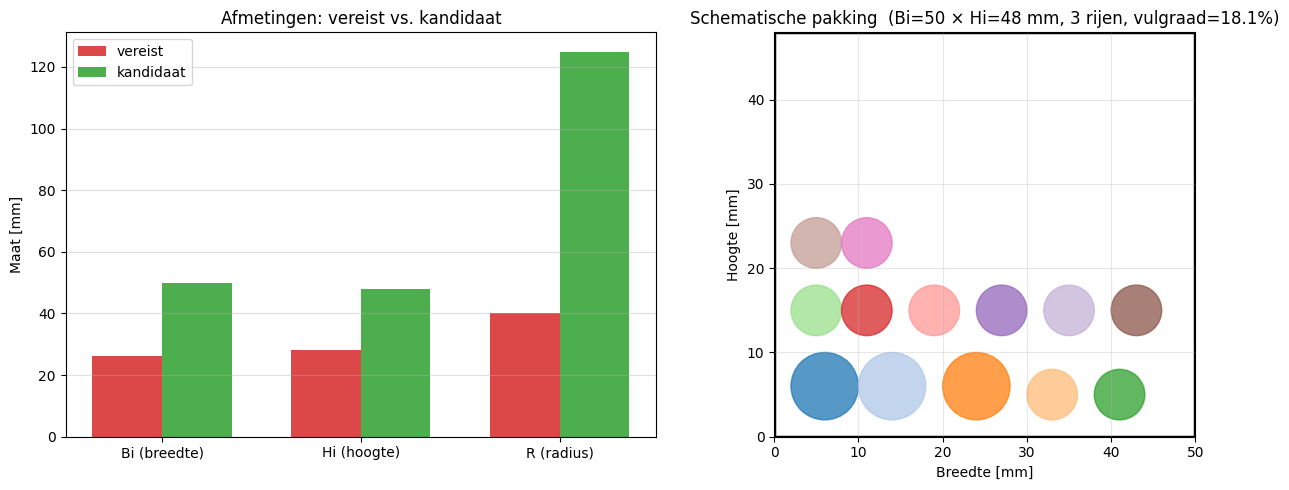

In [11]:
plot_kabelrups(resultaten_kabelrups, cfg_kabelrups)

In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# EXPORT
# ─────────────────────────────────────────────────────────────────────────────
resultaten_kabelrups_notebook = {
    "configuratie_kabelrups":  asdict(cfg_kabelrups),
    "kandidaat_kabelrups":     asdict(kandidaat_kabelrups),
    "kabeltabel":              kabeltabel.copy(),
    "resultaten_kabelrups":    {k: v for k, v in resultaten_kabelrups.items()
                                if k != "diameters"},
    "overzicht_kabelrups":     overzicht_kabelrups.copy(),
    "pass_fail_kabelrups":     pass_fail_kabelrups.copy(),
    "export_voor_volgende_modules": {
        "part_no":                   kandidaat_kabelrups.part_no,
        "vereiste_breedte_mm":       mm(resultaten_kabelrups["vereiste_breedte_min_m"])
                                     if not math.isnan(resultaten_kabelrups["vereiste_breedte_min_m"])
                                     else float("nan"),
        "vereiste_hoogte_mm":        mm(resultaten_kabelrups["hoogte_nodig_bij_Bi_m"]),
        "vereiste_radius_mm":        mm(resultaten_kabelrups["vereiste_radius_m"]),
        "kandidaat_breedte_mm":      mm(resultaten_kabelrups["kandidaat_Bi_m"]),
        "kandidaat_hoogte_mm":       mm(resultaten_kabelrups["kandidaat_Hi_m"]),
        "kandidaat_radius_mm":       mm(resultaten_kabelrups["kandidaat_radius_m"]),
        "vulgraad":                  resultaten_kabelrups["vulgraad"],
        "kettinglengte_berekend_m":  resultaten_kabelrups["kettinglengte_berekend_m"],
        "kettinglengte_m":           resultaten_kabelrups["kettinglengte_berekend_m"],  # alias
        "travel_catalogus_m":        resultaten_kabelrups["travel_catalogus_m"]
                                     if not math.isnan(resultaten_kabelrups["travel_catalogus_m"])
                                     else float("nan"),
        "kettinglengte_catalogus_m": resultaten_kabelrups["kettinglengte_catalogus_m"]
                                     if not math.isnan(resultaten_kabelrups["kettinglengte_catalogus_m"])
                                     else float("nan"),
        "ok_breedte":                bool(resultaten_kabelrups["ok_breedte"]),
        "ok_hoogte":                 bool(resultaten_kabelrups["ok_hoogte"]),
        "ok_radius":                 bool(resultaten_kabelrups["ok_radius"]),
        "ok_vulgraad":               bool(resultaten_kabelrups["ok_vulgraad"]),
        "ok_travel_catalogus":       bool(resultaten_kabelrups["ok_travel_catalogus"]),
        "geschikt_totaal":           bool(resultaten_kabelrups["geschikt_totaal"]),
    },
}

print("\n=== EXPORT VOOR VOLGENDE MODULES ===")
print(pd.Series(resultaten_kabelrups_notebook["export_voor_volgende_modules"]).to_string())


=== EXPORT VOOR VOLGENDE MODULES ===
part_no                      E2.48.050.125.0
vereiste_breedte_mm                     26.1
vereiste_hoogte_mm                      28.0
vereiste_radius_mm                      40.0
kandidaat_breedte_mm                    50.0
kandidaat_hoogte_mm                     48.0
kandidaat_radius_mm                    125.0
vulgraad                            0.180642
kettinglengte_berekend_m                 1.3
kettinglengte_m                          1.3
travel_catalogus_m                       3.0
kettinglengte_catalogus_m                NaN
ok_breedte                              True
ok_hoogte                               True
ok_radius                               True
ok_vulgraad                             True
ok_travel_catalogus                     True
geschikt_totaal                         True
